# Import Datasets

In [48]:
from sklearnex import patch_sklearn
patch_sklearn()

# Now import your normal sklearn modules
from sklearn.cluster import KMeans
# Your code will now automatically use Intel's hardware acceleration!

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("smartcart_customers.csv")
df = pd.DataFrame(data)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [3]:
print(df.shape)
df.isna().sum()

(2240, 22)


ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

### 1.Hande Missing values

In [4]:
# In above only Income Has null value so we fill with median  

In [5]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [6]:
df.sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
914,10619,1994,Graduation,Single,95529.0,0,0,03-12-2012,29,770,...,250,27,24,1,7,3,7,3,0,1
262,4200,1970,Master,Married,44159.0,1,0,17-06-2014,85,167,...,24,13,7,4,4,1,6,5,0,0
793,11075,1978,Graduation,Married,51267.0,1,1,29-10-2013,37,183,...,7,2,12,4,3,3,5,4,0,0
189,6431,1964,PhD,Married,45759.0,1,1,23-02-2013,13,42,...,3,0,4,2,2,0,3,7,0,0
1387,8702,1976,2n Cycle,Together,26907.0,1,1,20-08-2013,10,9,...,0,3,2,2,1,0,3,7,0,0


### 2.Year_Birth to Age

In [7]:
df["age"] = 2026 - df["Year_Birth"]

### 3. Dt_Customer to no day on that platform

In [8]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)

In [9]:
referance_date = df["Dt_Customer"].max()

In [10]:
df["Customer_Tenure_Days"]= (referance_date- df["Dt_Customer"]).dt.days

### 4.collabe All Purches

In [11]:
df["Total_Spending"] = df["MntWines"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntSweetProducts"]+df["MntFruits"]

### 5. Total Children

In [12]:
df["Total_Children"] = df["Kidhome"]+ df["Teenhome"]

### 6.Education

In [13]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [14]:
# we conver into only three categories Undergraduate ,Graduate , Postgraduate

In [15]:
df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate",
    "Graduation":"Graduate"
})
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

### 7.Marital Status

In [16]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [17]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow":"Alone",
    "Alone":"Alone",
    "Absurd":"Alone",
    "YOLO":"Alone"
})
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

## 8.Drop Columns

In [18]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spend_cols = ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']

In [19]:
drop_col = cols + spend_cols

In [20]:
df_cleaned = df.drop(drop_col,axis=1)

In [21]:
df_cleaned.shape

(2240, 15)

In [22]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,22,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,755,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,51,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,434,1,Partner


# Outliers

## Detection of Outliers Using pair plot

In [23]:
cols = ["Income","Recency","Response","age","Total_Spending","Total_Children"]

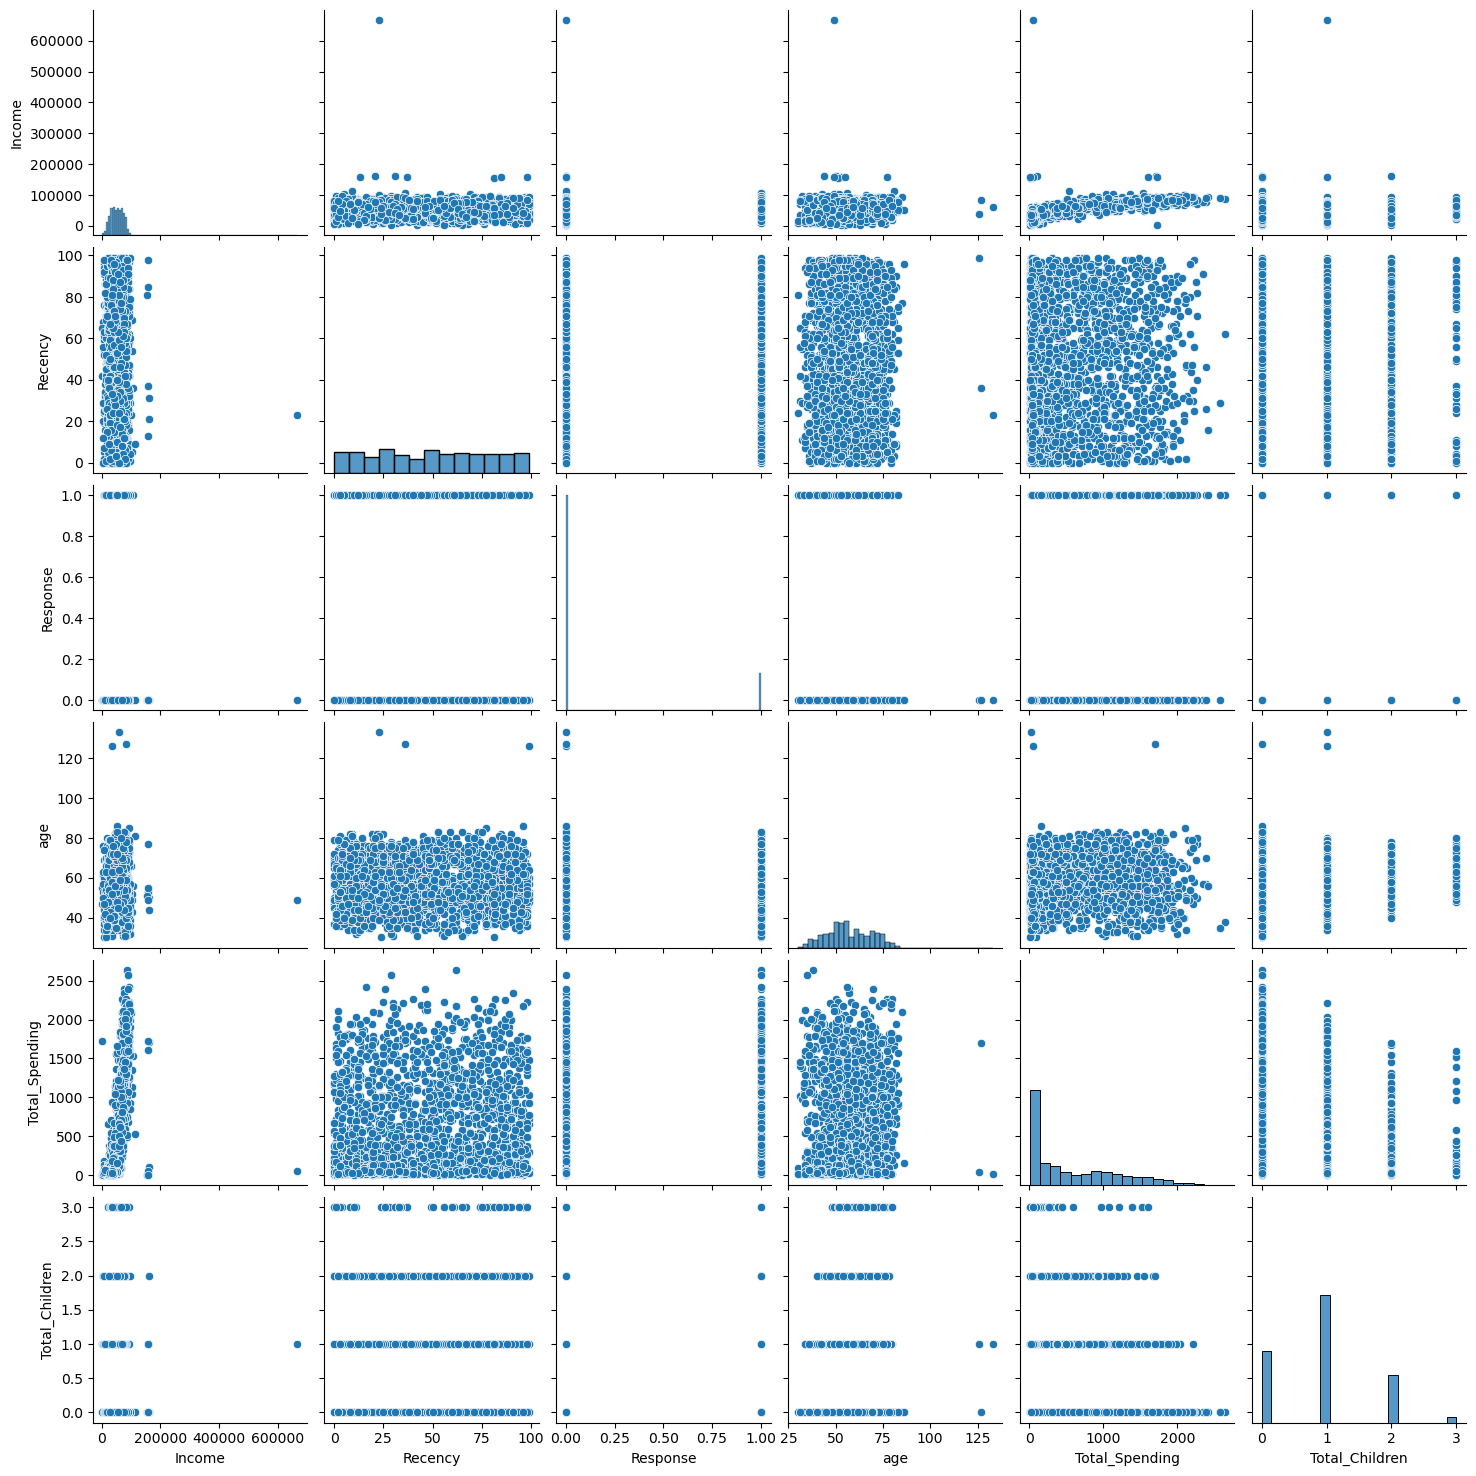

In [24]:
sns.pairplot(df_cleaned[cols])

#### in above chart we detect two outliers 
##### 1. age greter than 90  
##### 2. Income greater than 600000

In [25]:
print("Datasets size with Outliers",len(df_cleaned))

# remove those age is greater than 90
df_cleaned = df_cleaned[ df_cleaned["age"]<90]

# remove those income is grater than 600000
df_cleaned = df_cleaned[ df_cleaned["Income"]< 600000]

print("Datasets size WithOut Outliers",len(df_cleaned))

Datasets size with Outliers 2240
Datasets size WithOut Outliers 2236


# HeatMap

In [26]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

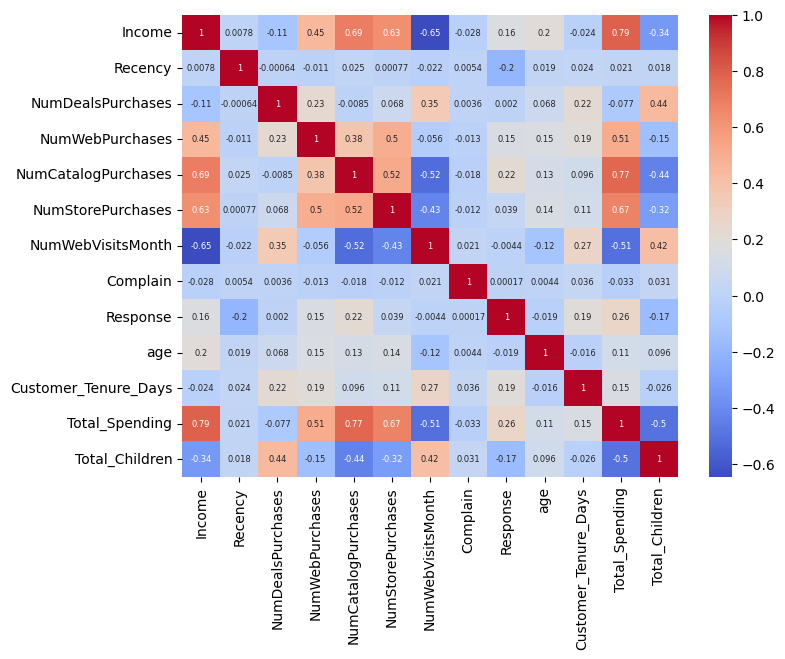

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={ "size": 6},
    cmap="coolwarm"
)

# Encodeing Data

In [28]:
from sklearn.preprocessing import OneHotEncoder

In [29]:
ohe = OneHotEncoder()
cat_col = ["Education","Living_With"]
enc_col = ohe.fit_transform(df_cleaned[cat_col])

In [30]:
enc_df = pd.DataFrame(
    enc_col.toarray(),
    columns=ohe.get_feature_names_out(cat_col),
    index= df_cleaned.index
)

In [31]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [32]:
df_encoded = pd.concat([df_cleaned.drop(cat_col,axis=1),enc_df],axis=1)
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,22,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,755,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,51,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,434,1,0.0,1.0,0.0,0.0,1.0


# Standardize the Data

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
sc = StandardScaler()
X_scaled = sc.fit_transform(df_encoded)

# Visualization

In [35]:
X_scaled.shape

(2236, 18)

In [36]:
from sklearn.decomposition import PCA

In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# variance 
pca.explained_variance_ratio_

array([0.23152136, 0.11385653])

<Axes: >

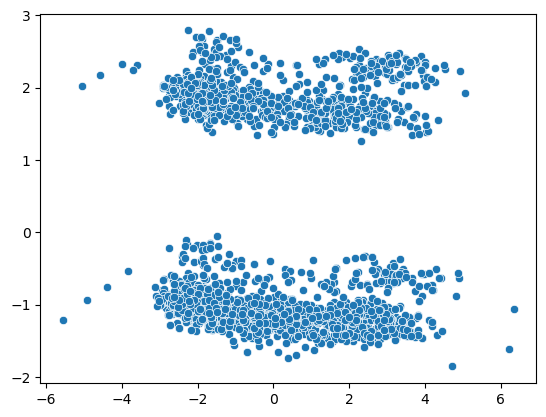

In [38]:
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1])

### 3d Visualization

In [39]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_ #Variance Ratio

array([0.23152136, 0.11385653, 0.10404589])

Text(0.5, 0.92, '3d Grapgh')

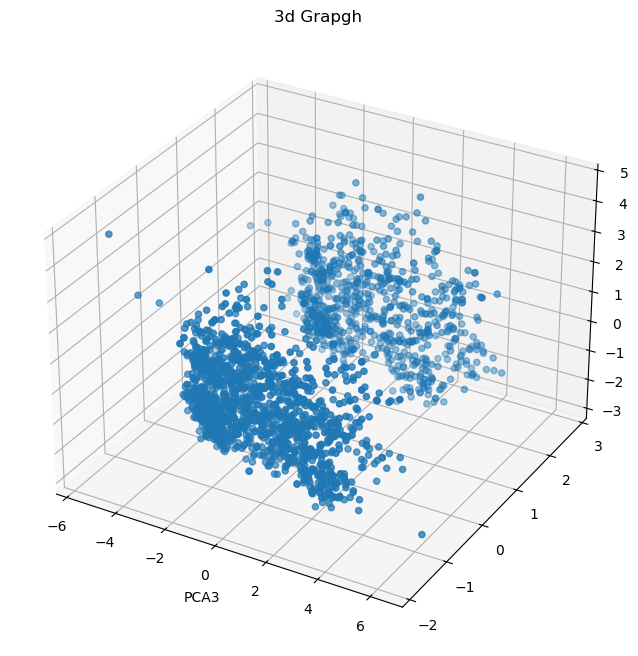

In [40]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])


ax.set_xlabel("PCA1")
ax.set_xlabel("PCA2")
ax.set_xlabel("PCA3")
ax.set_title("3d Grapgh")

# Analysis K value

## Elbow Method

In [41]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [49]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
    

C:\Users\sumit_mali\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


In [50]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [44]:
print("best k =", optimal_k)

best k = 4


Text(0, 0.5, 'WCSS')

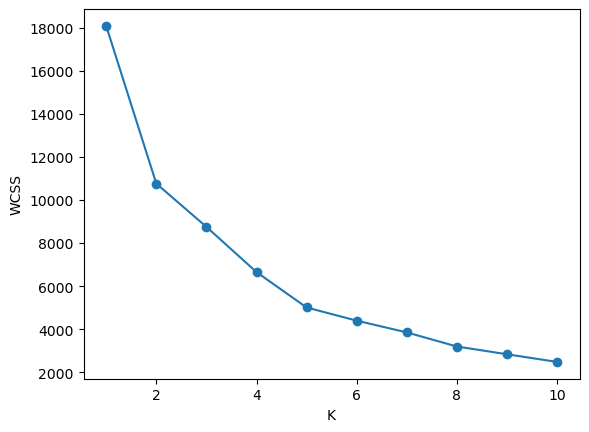

In [45]:
# plot

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

## 2. Silhouette Score

Text(0, 0.5, 'Silhouette score')

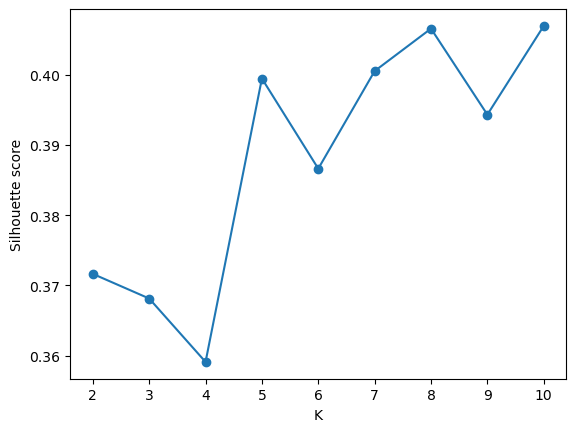

In [51]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# plot
plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

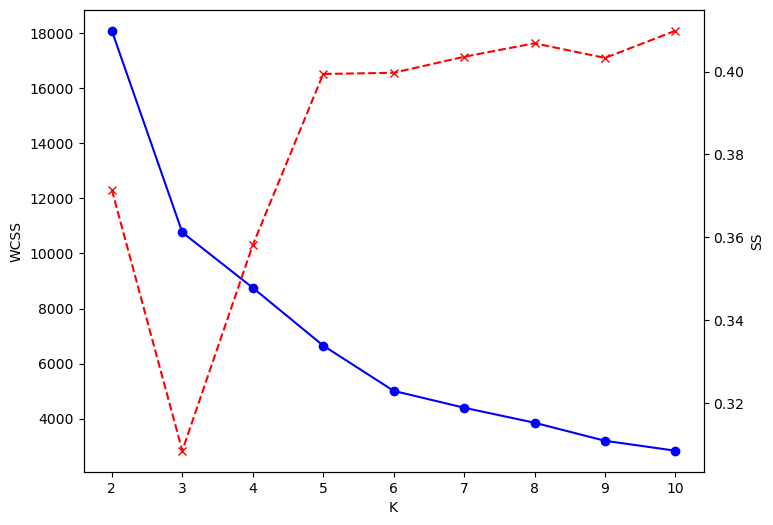

In [47]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

# Clustering

### KMeans

In [56]:
kmean = KMeans(
    n_clusters = 4,
    random_state =42
)

In [57]:
label = kmean.fit_predict(X_pca)

Text(0.5, 0.92, '3d Grapgh')

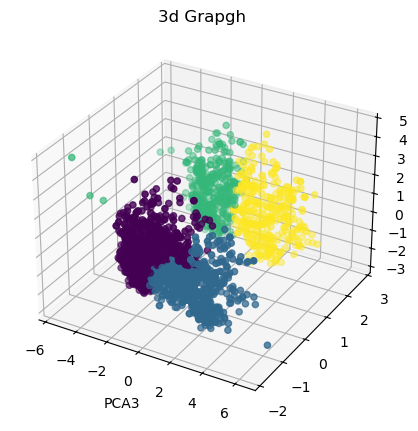

In [71]:
fig = plt.figure(figsize = (5,5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=label)


ax.set_xlabel("PCA1")
ax.set_xlabel("PCA2")
ax.set_xlabel("PCA3")
ax.set_title("3d Grapgh")

### Agglomerative

In [60]:
from sklearn.cluster import AgglomerativeClustering

In [86]:
agg = AgglomerativeClustering(n_clusters=4,linkage="ward",)

In [87]:
label= agg.fit_predict(X_pca)

Text(0.5, 0.92, '3d Grapgh')

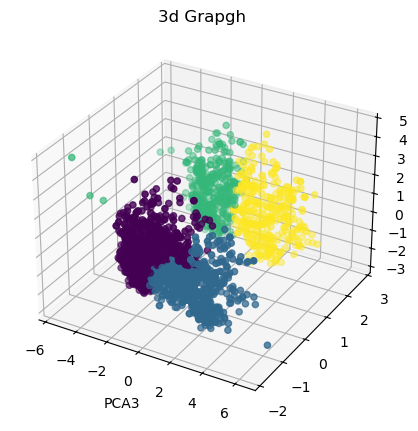

In [88]:
fig = plt.figure(figsize = (5,5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=label)


ax.set_xlabel("PCA1")
ax.set_xlabel("PCA2")
ax.set_xlabel("PCA3")
ax.set_title("3d Grapgh")

#####  Here we not use DBSCAN  because is take a automatic cluster so here it take automatically more than 30 cluster so it not suitable for us project

## Now we use Aggelomerative CLustering

In [95]:
df_cleaned["cluster"] = label
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,22,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,755,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,51,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,434,1,Partner


<Axes: xlabel='cluster', ylabel='count'>

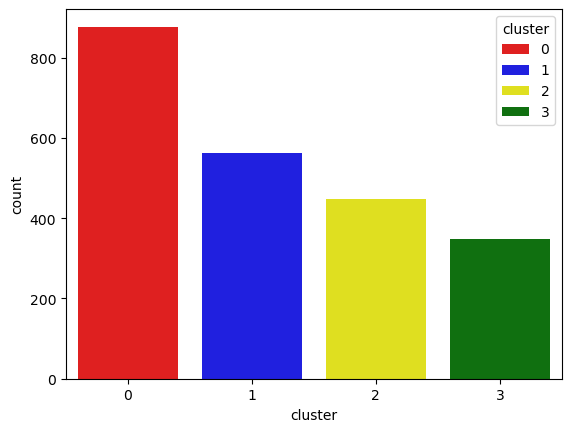

In [94]:
pal=["red","blue","yellow","green"]
sns.countplot(x=df_cleaned["cluster"],palette=pal, hue=df_cleaned["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

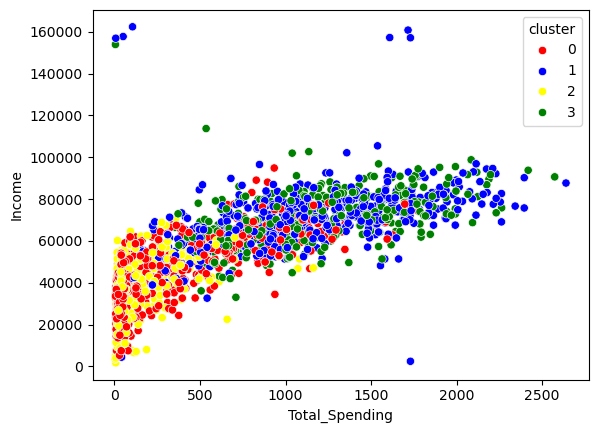

In [96]:
sns.scatterplot(x=df_cleaned["Total_Spending"],y=df_cleaned["Income"],hue=df_cleaned["cluster"],palette=pal)

# Cluster Summery 

In [101]:
df_encoded["cluster"] = label

In [102]:
cluster_Summery = df_encoded.groupby("cluster").mean()
print(cluster_Summery)



               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        40359.657925  49.011403           2.680730         3.232611   
1        70098.247331  49.037367           1.855872         5.437722   
2        37056.037946  48.553571           2.582589         2.772321   
3        70986.547278  50.229226           1.862464         5.750716   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   1.174458           4.322691           6.403649  0.007982   
1                   4.951957           8.154804           3.565836  0.010676   
2                   0.841518           3.645089           6.638393  0.011161   
3                   5.057307           8.458453           3.722063  0.005731   

         Response        age  Customer_Tenure_Days  Total_Spending  \
cluster         